# Import libraries

In [ ]:
!gdown 194DqJkUjjtlUCp7Sd2DkXgwu7SuBFsrj

!unzip -q celeba_hq_256.zip

Downloading...
From (original): https://drive.google.com/uc?id=194DqJkUjjtlUCp7Sd2DkXgwu7SuBFsrj
From (redirected): https://drive.google.com/uc?id=194DqJkUjjtlUCp7Sd2DkXgwu7SuBFsrj&confirm=t&uuid=6e98d4ef-6ece-4803-b0eb-c5beb7e11df5
To: /content/celeba_hq_256.zip
100% 297M/297M [00:07<00:00, 38.7MB/s]


In [ ]:
import os
import random
import math
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid
from torchvision.transforms import ToPILImage

In [ ]:
IMG_DIR = "./celeba_hq_256"

SEED = 42

TRAIN_RATIO = 0.9
TRAIN_SIZE = 10000
TEST_SIZE = 100
BATCH_SIZE = 64

IMAGE_SIZE = 64
CHANNELS = (128, 128, 256, 256)

In [ ]:
def set_seed(seed=42):
	random.seed(seed)
	os.environ['PYTHONHASHSEED'] = str(seed)
	np.random.seed(seed)

	torch.manual_seed(seed)

	if torch.backends.mps.is_available():
		torch.mps.manual_seed(seed)
		os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

	if torch.cuda.is_available():
		torch.cuda.manual_seed(seed)
		torch.cuda.manual_seed_all(seed)
		torch.backends.cudnn.deterministic = True
		torch.backends.cudnn.benchmark = False

	try:
		torch.use_deterministic_algorithms(True)
	except RuntimeError:
		pass

set_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Utils

In [ ]:
def denormalize(x):
    # Convert [-1, 1] -> [0, 1]
    return (x + 1) / 2


def show_batch(images, nrow=8, title=None):
    images = denormalize(images.detach().cpu()).clamp(0, 1)
    grid = make_grid(images, nrow=nrow, padding=2)
    img = ToPILImage()(grid)

    plt.figure(figsize=(14, 6))
    if title is not None:
        plt.title(title)
    plt.imshow(img)
    plt.axis("off")
    plt.show()


def compose_inpaint(pred_image, masked_image, mask):
    return masked_image * (1 - mask) + pred_image * mask

In [ ]:
def masked_l1_loss(pred, target, mask, eps=1e-8):
    """
    Tính L1 trung bình chỉ trên vùng mask.
    pred, target: [B, 3, H, W]
    mask: [B, 1, H, W]
    """
    loss = torch.abs(pred - target) * mask
    return loss.sum() / (mask.sum() * pred.shape[1] + eps)


def masked_mse_loss(pred, target, mask, eps=1e-8):
    """
    Tính MSE trung bình chỉ trên vùng mask.
    """
    loss = ((pred - target) ** 2) * mask
    return loss.sum() / (mask.sum() * pred.shape[1] + eps)


In [ ]:
def load_checkpoint(
    checkpoint_path,
    model_type,
    device,
    image_size=256,
    z_dim=256,
    channels=(64, 128, 256, 256),
):
    """
    model_type:
        "vae"
        "diffusion"
        "flow"
    """

    model_type = model_type.lower()

    if model_type == "vae":
        model = ConditionalUNetVAE(
            image_size=image_size,
            z_dim=z_dim,
            channels=channels,
            layers_per_block=2,
        ).to(device)

    else:
        raise ValueError(
            f"Unknown model_type={model_type}. "
            "Use 'vae', 'diffusion', or 'flow'."
        )

    state_dict = torch.load(
        checkpoint_path,
        map_location=device
    )

    model.load_state_dict(state_dict)
    model.eval()

    print(f"Loaded {model_type} checkpoint from: {checkpoint_path}")

    return model

# Dataset & Dataloader

In [ ]:
def bbox2mask(img_shape, bbox, dtype="uint8"):
    """
    bbox = (top, left, height, width)
    mask = 1 ở vùng bị che, 0 ở vùng giữ lại.
    """
    height, width = img_shape[:2]

    mask = np.zeros((height, width, 1), dtype=dtype)
    mask[
        bbox[0]:bbox[0] + bbox[2],
        bbox[1]:bbox[1] + bbox[3],
        :
    ] = 1

    return mask

In [ ]:
class InpaintingDataset(Dataset):
    def __init__(self, img_paths, image_size=(256, 256), random_mask=False):
        self.img_paths = img_paths
        self.image_size = image_size
        self.random_mask = random_mask

        self.tfs = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5]
            )
        ])

    def __len__(self):
        return len(self.img_paths)

    def get_mask(self):
        h, w = self.image_size

        if self.random_mask:
            mask_h = random.randint(h // 4, h // 2)
            mask_w = random.randint(w // 4, w // 2)

            top = random.randint(0, h - mask_h)
            left = random.randint(0, w - mask_w)
        else:
            # Validation / test dùng center mask giống Diffusion và Flow Matching
            mask_h = h // 3
            mask_w = w // 3

            top = (h - mask_h) // 2
            left = (w - mask_w) // 2

        mask = bbox2mask(
            self.image_size,
            bbox=(top, left, mask_h, mask_w)
        )

        mask = torch.from_numpy(mask).permute(2, 0, 1).float()
        return mask

    def __getitem__(self, index):
        img_path = self.img_paths[index]

        img = Image.open(img_path).convert("RGB")
        gt_image = self.tfs(img)

        mask = self.get_mask()

        # Condition chung cho VAE / Diffusion / Flow Matching:
        # known region giữ ảnh thật, missing region fill bằng -1
        cond_image = gt_image * (1 - mask) + (-1.0) * mask

        return {
            "gt_image": gt_image,
            "cond_image": cond_image,
            "mask": mask,
            "path": img_path,
        }

In [ ]:
file_names = sorted(os.listdir(IMG_DIR))
img_paths = [os.path.join(IMG_DIR, f) for f in file_names]

random.shuffle(img_paths)

split_idx = int(len(img_paths) * TRAIN_RATIO)

train_imgpaths = img_paths[:split_idx]
val_imgpaths = img_paths[split_idx:]

# Using small data for training, the original dataset is very large
train_imgpaths = train_imgpaths[:TRAIN_SIZE]
val_imgpaths = val_imgpaths[:TEST_SIZE]

print("Train:", len(train_imgpaths))
print("Val:", len(val_imgpaths))

Train: 10000
Val: 100


In [ ]:
train_dataset = InpaintingDataset(
    train_imgpaths,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    random_mask=False,
)

val_dataset = InpaintingDataset(
    val_imgpaths,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    random_mask=False,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=8,
    pin_memory=True,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    drop_last=False,
)

print("Train loader:", len(train_loader))
print("Val loader:", len(val_loader))

Train loader: 156
Val loader: 2


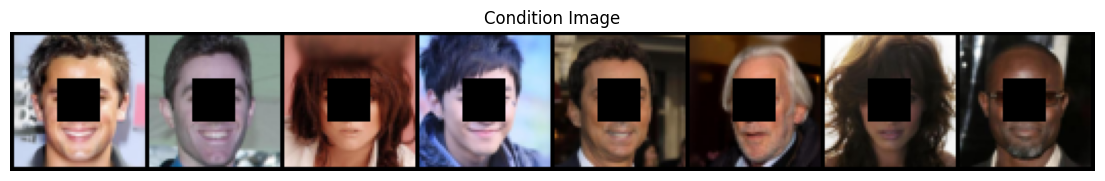

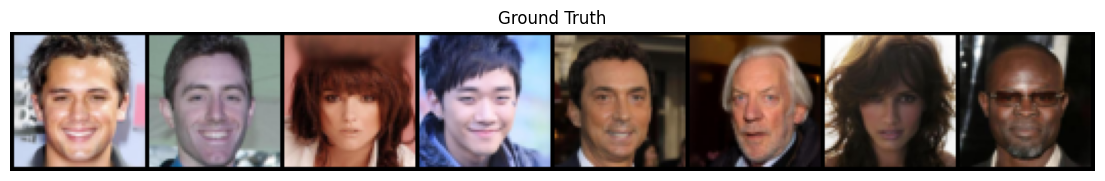

In [ ]:
sample = next(iter(train_loader))

gt_image = sample["gt_image"]
cond_image = sample["cond_image"]
mask = sample["mask"]

show_batch(cond_image[:8], nrow=8, title="Condition Image")
show_batch(gt_image[:8], nrow=8, title="Ground Truth")

# Model

## Model definition

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_norm=True):
        super().__init__()

        layers = [
            nn.Conv2d(
                in_ch,
                out_ch,
                kernel_size=3,
                padding=1,
                bias=not use_norm,
            )
        ]

        if use_norm:
            layers.append(nn.BatchNorm2d(out_ch))

        layers.append(nn.SiLU(inplace=True))

        self.block = nn.Sequential(*layers)

        self.skip = (
            nn.Conv2d(in_ch, out_ch, kernel_size=1)
            if in_ch != out_ch else nn.Identity()
        )

    def forward(self, x):
        return self.block(x) + self.skip(x)

In [ ]:
class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, layers=2):
        super().__init__()

        blocks = [ConvBlock(in_ch, out_ch)]

        for _ in range(layers - 1):
            blocks.append(ConvBlock(out_ch, out_ch))

        self.res = nn.Sequential(*blocks)

        self.down = nn.Sequential(
            nn.Conv2d(
                out_ch,
                out_ch,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_ch),
            nn.SiLU(inplace=True),
        )

    def forward(self, x):
        skip = self.res(x)
        out = self.down(skip)
        return out, skip

In [ ]:
class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, layers=2, upscale_factor=2):
        super().__init__()

        self.up = nn.Sequential(
            nn.Conv2d(
                in_ch,
                out_ch * upscale_factor ** 2,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.PixelShuffle(upscale_factor),
            nn.BatchNorm2d(out_ch),
            nn.SiLU(inplace=True),
        )

        blocks = [ConvBlock(out_ch + skip_ch, out_ch)]

        for _ in range(layers - 1):
            blocks.append(ConvBlock(out_ch, out_ch))

        self.res = nn.Sequential(*blocks)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.res(x)
        return x

In [ ]:
class ConditionalUNetVAE(nn.Module):
    def __init__(
        self,
        image_size=256,
        z_dim=256,
        channels=(64, 128, 256, 256),
        layers_per_block=2,
    ):
        super().__init__()

        self.image_size = image_size
        self.z_dim = z_dim
        self.channels = channels

        c1, c2, c3, c4 = channels

        # condition encoder: cond RGB + mask = 4 channels
        self.cond_in = nn.Sequential(
            nn.Conv2d(4, c1, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c1),
            nn.SiLU(inplace=True),
        )

        self.cond_d1 = DownBlock(c1, c1, layers_per_block)  # 256 -> 128
        self.cond_d2 = DownBlock(c1, c2, layers_per_block)  # 128 -> 64
        self.cond_d3 = DownBlock(c2, c3, layers_per_block)  # 64 -> 32
        self.cond_d4 = DownBlock(c3, c4, layers_per_block)  # 32 -> 16

        self.cond_mid = ConvBlock(c4, c4)

        # posterior encoder: gt RGB + cond RGB + mask = 7 channels
        self.post_in = nn.Sequential(
            nn.Conv2d(7, c1, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c1),
            nn.SiLU(inplace=True),
        )

        self.post_d1 = DownBlock(c1, c1, layers_per_block)
        self.post_d2 = DownBlock(c1, c2, layers_per_block)
        self.post_d3 = DownBlock(c2, c3, layers_per_block)
        self.post_d4 = DownBlock(c3, c4, layers_per_block)

        self.post_mid = ConvBlock(c4, c4)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc_mu = nn.Linear(c4 * 2, z_dim)
        self.fc_logvar = nn.Linear(c4 * 2, z_dim)

        self.latent_hw = image_size // 32

        self.fc_z = nn.Linear(
            z_dim,
            c4 * self.latent_hw * self.latent_hw,
        )

        self.z_up = nn.Sequential(
            nn.Conv2d(
                c4,
                c4 * 4,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.PixelShuffle(2),
            nn.BatchNorm2d(c4),
            nn.SiLU(inplace=True),
        )

        self.dec_mid = ConvBlock(c4 * 2, c4)

        self.up4 = UpBlock(c4, c4, c3, layers_per_block)
        self.up3 = UpBlock(c3, c3, c2, layers_per_block)
        self.up2 = UpBlock(c2, c2, c1, layers_per_block)
        self.up1 = UpBlock(c1, c1, c1, layers_per_block)

        self.out = nn.Sequential(
            nn.BatchNorm2d(c1),
            nn.SiLU(inplace=True),
            nn.Conv2d(c1, 3, kernel_size=3, padding=1),
            nn.Tanh(),
        )

    def encode_condition(self, cond_image, mask):
        x = torch.cat([cond_image, mask], dim=1)

        x = self.cond_in(x)

        x, s1 = self.cond_d1(x)
        x, s2 = self.cond_d2(x)
        x, s3 = self.cond_d3(x)
        x, s4 = self.cond_d4(x)

        x = self.cond_mid(x)

        return x, (s1, s2, s3, s4)

    def encode_posterior(self, gt_image, cond_image, mask, cond_deep):
        x = torch.cat([gt_image, cond_image, mask], dim=1)

        x = self.post_in(x)

        x, _ = self.post_d1(x)
        x, _ = self.post_d2(x)
        x, _ = self.post_d3(x)
        x, _ = self.post_d4(x)

        x = self.post_mid(x)

        h = torch.cat([x, cond_deep], dim=1)
        h = self.pool(h).flatten(1)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, cond_image, mask, cond_feats):
        cond_deep, skips = cond_feats
        s1, s2, s3, s4 = skips

        h = self.fc_z(z)

        h = h.view(
            z.size(0),
            self.channels[-1],
            self.latent_hw,
            self.latent_hw,
        )

        h = self.z_up(h)

        h = torch.cat([h, cond_deep], dim=1)
        h = self.dec_mid(h)

        h = self.up4(h, s4)
        h = self.up3(h, s3)
        h = self.up2(h, s2)
        h = self.up1(h, s1)

        pred_image = self.out(h)

        final_image = compose_inpaint(
            pred_image,
            cond_image,
            mask,
        )

        return final_image, pred_image

    def forward(self, gt_image, cond_image, mask):
        cond_feats = self.encode_condition(cond_image, mask)
        cond_deep, _ = cond_feats

        mu, logvar = self.encode_posterior(
            gt_image,
            cond_image,
            mask,
            cond_deep,
        )

        z = self.reparameterize(mu, logvar)

        final_image, pred_image = self.decode(
            z,
            cond_image,
            mask,
            cond_feats,
        )

        return final_image, pred_image, mu, logvar

    @torch.no_grad()
    def sample(self, cond_image, mask):
        cond_feats = self.encode_condition(cond_image, mask)

        z = torch.randn(
            cond_image.size(0),
            self.z_dim,
            device=cond_image.device,
        )

        final_image, pred_image = self.decode(
            z,
            cond_image,
            mask,
            cond_feats,
        )

        return final_image, pred_image

In [ ]:
vae_model = ConditionalUNetVAE(
    image_size=IMAGE_SIZE,
    z_dim=256,
    channels=CHANNELS,
    layers_per_block=2,
).to(device)

vae_optimizer = torch.optim.AdamW(
    vae_model.parameters(),
    lr=5e-5,
    weight_decay=1e-3,
)

total_params = sum(
    p.numel() for p in vae_model.parameters()
    if p.requires_grad
)
print(f"VAE total parameters: {total_params:,}")

os.makedirs("VAE", exist_ok=True)

VAE total parameters: 24,234,115


## Loss function

In [ ]:
def vae_loss_fn(
    final_image,
    gt_image,
    mask,
    mu,
    logvar,
    beta=1e-4,
    use_mse=True,
):
    rec_l1 = masked_l1_loss(
        final_image,
        gt_image,
        mask
    )

    rec_mse_value = 0.0

    if use_mse:
        rec_mse = masked_mse_loss(
            final_image,
            gt_image,
            mask
        )
        rec_loss = rec_l1 + 0.1 * rec_mse
        rec_mse_value = rec_mse.item()
    else:
        rec_loss = rec_l1

    kl_loss = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    loss = rec_loss + beta * kl_loss

    return loss, {
        "rec_loss": rec_loss.item(),
        "rec_l1": rec_l1.item(),
        "rec_mse": rec_mse_value,
        "kl_loss": kl_loss.item(),
    }

## Evaluate

In [ ]:
@torch.no_grad()
def evaluate_vae(
    vae,
    val_loader,
    beta=1e-4,
    use_mse=True,
):
    vae.eval()

    total_loss = 0.0
    total_rec = 0.0
    total_l1 = 0.0
    total_mse = 0.0
    total_kl = 0.0

    for data in val_loader:
        gt_image = data["gt_image"].to(device)
        cond_image = data["cond_image"].to(device)
        mask = data["mask"].to(device).float()

        final_image, pred_image, mu, logvar = vae(
            gt_image,
            cond_image,
            mask
        )

        loss, loss_dict = vae_loss_fn(
            final_image=final_image,
            gt_image=gt_image,
            mask=mask,
            mu=mu,
            logvar=logvar,
            beta=beta,
            use_mse=use_mse,
        )

        total_loss += loss.item()
        total_rec += loss_dict["rec_loss"]
        total_l1 += loss_dict["rec_l1"]
        total_mse += loss_dict["rec_mse"]
        total_kl += loss_dict["kl_loss"]

    n = len(val_loader)

    return {
        "val_loss": total_loss / n,
        "val_rec": total_rec / n,
        "val_l1": total_l1 / n,
        "val_mse": total_mse / n,
        "val_kl": total_kl / n,
    }

## Training

In [ ]:
vae_epochs = 50
vae_beta = 5e-4
kl_warmup_epochs = 10

best_val_loss = float("inf")
patience = 8
epochs_no_improve = 0

for epoch in range(vae_epochs):
    vae_model.train()

    total_loss = 0.0
    total_rec = 0.0
    total_l1 = 0.0
    total_mse = 0.0
    total_kl = 0.0

    current_beta = min(
        vae_beta,
        vae_beta * (epoch + 1) / kl_warmup_epochs
    )

    pbar = tqdm(
        train_loader,
        desc=f"[VAE] Epoch {epoch + 1}/{vae_epochs}"
    )

    for data in pbar:
        gt_image = data["gt_image"].to(device)
        cond_image = data["cond_image"].to(device)
        mask = data["mask"].to(device).float()

        final_image, pred_image, mu, logvar = vae_model(
            gt_image,
            cond_image,
            mask
        )

        loss, loss_dict = vae_loss_fn(
            final_image=final_image,
            gt_image=gt_image,
            mask=mask,
            mu=mu,
            logvar=logvar,
            beta=current_beta,
            use_mse=True,
        )

        vae_optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(vae_model.parameters(), max_norm=1.0)
        vae_optimizer.step()

        total_loss += loss.item()
        total_rec += loss_dict["rec_loss"]
        total_l1 += loss_dict["rec_l1"]
        total_mse += loss_dict["rec_mse"]
        total_kl += loss_dict["kl_loss"]

        pbar.set_postfix({
            "loss": loss.item(),
            "rec": loss_dict["rec_loss"],
            "l1": loss_dict["rec_l1"],
            "mse": loss_dict["rec_mse"],
            "kl": loss_dict["kl_loss"],
            "beta": current_beta,
        })

    train_loss = total_loss / len(train_loader)
    train_rec = total_rec / len(train_loader)
    train_l1 = total_l1 / len(train_loader)
    train_mse = total_mse / len(train_loader)
    train_kl = total_kl / len(train_loader)

    val_metrics = evaluate_vae(
        vae=vae_model,
        val_loader=val_loader,
        beta=current_beta,
        use_mse=True,
    )

    print(
        f"[VAE] Epoch {epoch + 1}: "
        f"train_loss={train_loss:.5f}, "
        f"train_rec={train_rec:.5f}, "
        f"train_l1={train_l1:.5f}, "
        f"train_mse={train_mse:.5f}, "
        f"train_kl={train_kl:.5f}, "
        f"val_loss={val_metrics['val_loss']:.5f}, "
        f"val_rec={val_metrics['val_rec']:.5f}, "
        f"val_l1={val_metrics['val_l1']:.5f}, "
        f"val_mse={val_metrics['val_mse']:.5f}, "
        f"val_kl={val_metrics['val_kl']:.5f}, "
        f"beta={current_beta:.8f}"
    )

    if (epoch + 1) % 10 == 0:
        torch.save(
            vae_model.state_dict(),
            f"VAE/vae_epoch_{epoch + 1}.pth"
        )

    if val_metrics["val_loss"] < best_val_loss:
        best_val_loss = val_metrics["val_loss"]
        epochs_no_improve = 0

        torch.save(
            vae_model.state_dict(),
            "VAE/vae_best.pth"
        )

        print(
            f"Saved best checkpoint at epoch {epoch + 1} "
            f"with val_loss={best_val_loss:.5f}"
        )
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve}/{patience} epochs.")

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch + 1}.")
            break

[VAE] Epoch 1/50: 100%|██████████| 156/156 [00:59<00:00,  2.64it/s, loss=0.117, rec=0.117, l1=0.114, mse=0.027, kl=0.239, beta=5e-5]


[VAE] Epoch 1: train_loss=0.15984, train_rec=0.15983, train_l1=0.15499, train_mse=0.04836, train_kl=0.18530, val_loss=0.14214, val_rec=0.14210, val_l1=0.13842, val_mse=0.03686, val_kl=0.80726, beta=0.00005000
Saved best checkpoint at epoch 1 with val_loss=0.14214


[VAE] Epoch 2/50: 100%|██████████| 156/156 [00:58<00:00,  2.68it/s, loss=0.109, rec=0.109, l1=0.106, mse=0.0241, kl=0.348, beta=0.0001]


[VAE] Epoch 2: train_loss=0.11655, train_rec=0.11652, train_l1=0.11388, train_mse=0.02637, train_kl=0.30109, val_loss=0.10685, val_rec=0.10682, val_l1=0.10454, val_mse=0.02280, val_kl=0.30733, beta=0.00010000
Saved best checkpoint at epoch 2 with val_loss=0.10685


[VAE] Epoch 3/50: 100%|██████████| 156/156 [00:58<00:00,  2.68it/s, loss=0.103, rec=0.103, l1=0.101, mse=0.0213, kl=0.352, beta=0.00015]


...

[VAE] Epoch 24: train_loss=0.05168, train_rec=0.05133, train_l1=0.05083, train_mse=0.00505, train_kl=0.68835, val_loss=0.08253, val_rec=0.08219, val_l1=0.08073, val_mse=0.01463, val_kl=0.67754, beta=0.00050000
No improvement for 6/8 epochs.


[VAE] Epoch 25/50: 100%|██████████| 156/156 [00:58<00:00,  2.68it/s, loss=0.05, rec=0.0496, l1=0.0492, mse=0.0048, kl=0.702, beta=0.0005]


[VAE] Epoch 25: train_loss=0.05078, train_rec=0.05044, train_l1=0.04995, train_mse=0.00486, train_kl=0.68131, val_loss=0.08528, val_rec=0.08495, val_l1=0.08346, val_mse=0.01497, val_kl=0.64617, beta=0.00050000
No improvement for 7/8 epochs.


[VAE] Epoch 26/50: 100%|██████████| 156/156 [00:58<00:00,  2.68it/s, loss=0.0544, rec=0.054, l1=0.0535, mse=0.00551, kl=0.683, beta=0.0005]


[VAE] Epoch 26: train_loss=0.04953, train_rec=0.04920, train_l1=0.04873, train_mse=0.00463, train_kl=0.67873, val_loss=0.08796, val_rec=0.08762, val_l1=0.08604, val_mse=0.01576, val_kl=0.67726, beta=0.00050000
No improvement for 8/8 epochs.
Early stopping at epoch 26.


## Inference

In [ ]:
vae = load_checkpoint(
    checkpoint_path="VAE/vae_best.pth",
    model_type="vae",
    device=device,
    image_size=IMAGE_SIZE,
    z_dim=256,
    channels=(128, 128, 256, 256),
)

all_gt = []
all_cond = []
all_result = []

vae.eval()

for sample in val_loader:
    with torch.no_grad():
        gt_image = sample["gt_image"].to(device)
        cond_image = sample["cond_image"].to(device)
        mask = sample["mask"].to(device).float()

        final_sample, pred_sample = vae.sample(
            cond_image,
            mask
        )

        all_gt.append(gt_image.detach().cpu())
        all_cond.append(cond_image.detach().cpu())
        all_result.append(final_sample.detach().cpu())

all_gt = torch.cat(all_gt, dim=0)
all_cond = torch.cat(all_cond, dim=0)
all_result = torch.cat(all_result, dim=0)

print("Generated:", all_result.shape)

Loaded vae checkpoint from: VAE/vae_best.pth
Generated: torch.Size([100, 3, 64, 64])


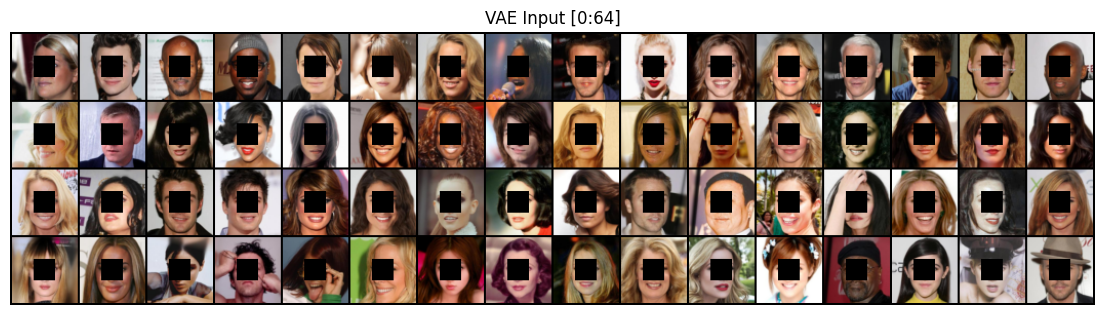

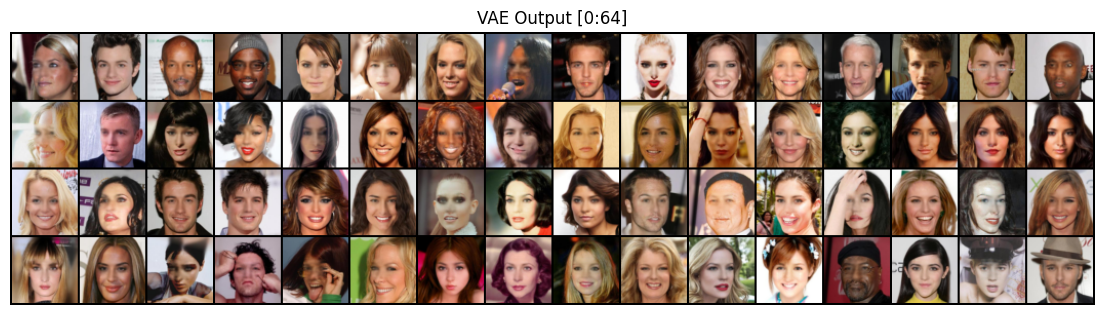

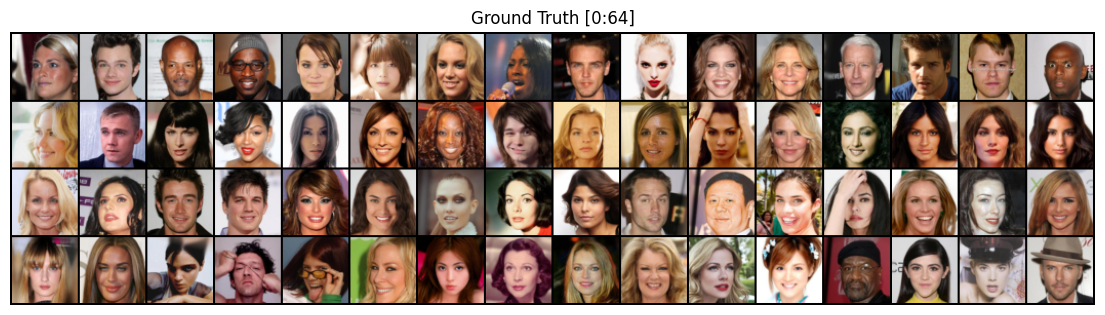

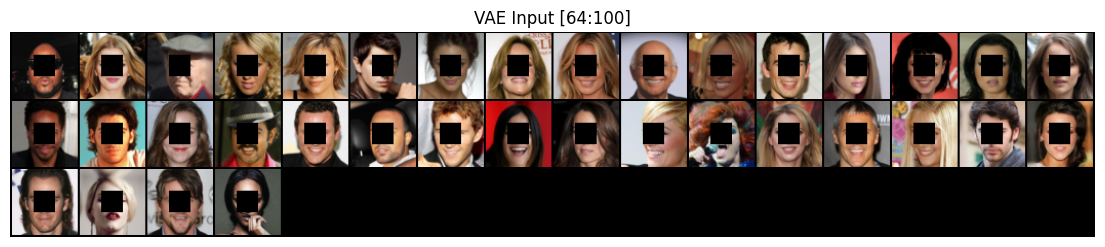

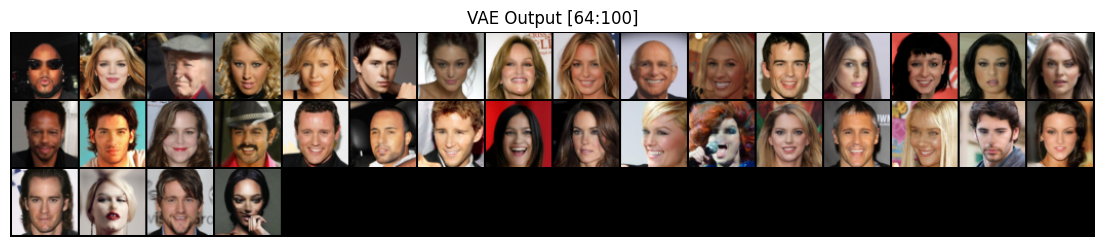

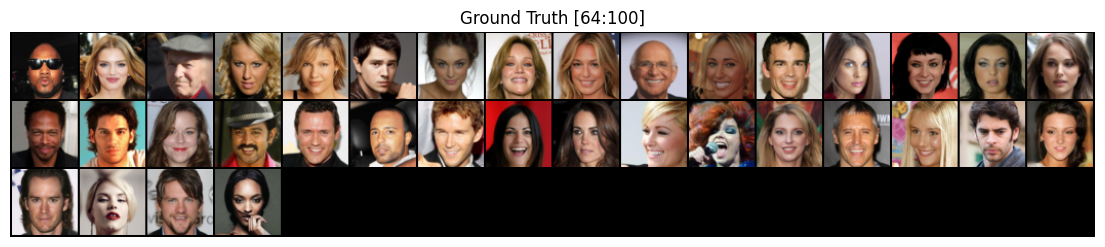

In [ ]:
display_batch = BATCH_SIZE
num_images = all_result.size(0)

for start in range(0, num_images, display_batch):
    end = min(start + display_batch, num_images)

    show_batch(
        all_cond[start:end],
        nrow=16,
        title=f"VAE Input [{start}:{end}]"
    )

    show_batch(
        all_result[start:end],
        nrow=16,
        title=f"VAE Output [{start}:{end}]"
    )

    show_batch(
        all_gt[start:end],
        nrow=16,
        title=f"Ground Truth [{start}:{end}]"
    )